# Exercise 2 — Flood impact for one storm of the flood-map library — Saint John's, Antigua

The UFFIS forecast for Antigua does not run a hydraulic model when a storm approaches.
Instead each parish has a **library of 200 synthetic storms**, each with a precomputed
maximum flood-depth map, and the forecast picks from it. This notebook opens the
library for Saint John's parish — the capital, and where most of the exposure is —
takes one storm out of it and works out what its flood actually touches: how deep the
water gets on each individual building and road, and how many people, how much floor
area and how many kilometres of road that adds up to.

The question being answered is:

> **In storm 150, how deep is the water on each building and road in Saint John's?**

Depth is a physical quantity, so the answer needs no reference to a threshold — worth
contrasting with Exercise 3, which works from *probabilities* across a forecast and
therefore does need one. Section 9 shows how the two connect.

**What to take away from it**

- how to read one slice out of a large Zarr store without pulling the whole array
- how to sample a raster onto tens of thousands of polygons in a single pass, why the
  *maximum* over a footprint is the defensible choice, and how to notice when a
  sampling method is not fit for the grid
- where each number in an impact table comes from, and which decisions along the way
  change it
- how a forecast turns a library of scenarios into the probability rasters of Exercise 3

**Workflow**

1. Open the storm library and look at one storm
2. Read the storm index: which storms exist and how big they are
3. Load the buildings and roads of Saint John's
4. Sample the deepest water on each feature's own footprint
5. Group into depth bands and build the impact table
6. Map it
7. See how impact grows across the library
8. From library to forecast: how the probability rasters are made

Everything is read from a public S3 bucket. Nothing needs to be downloaded first.

In [1]:
import sys

# Google Colab ships geopandas but not zarr 3, rasterio or pyogrio. A local
# environment made with `pip install -e .` from the plugin repo has everything.
if "google.colab" in sys.modules:
    %pip install -q "zarr>=3" rasterio pyogrio

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import zarr
from zarr.storage import FsspecStore

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
STORE = f"{BUCKET}/AnB_IBF/AG04_SaintJohnS_v1.zarr"      # Saint John's flood-map library
FEATURES = f"{BUCKET}/antigua_barbuda_IBF/AntiguaBarbuda_Jerry_cycle_10151010_IBF_outputs.gpkg"
PARISH = "ATG.4_1"                                         # Saint John's in the geopackage (GID_1)

print("ready")

ready


## 1. The storm library

The flood maps live in a **Zarr store** — an array split into many small files, so
you can read one slice without downloading the whole thing. The `depth` array here is
200 storms × 465 rows × 428 columns of float32, about 160 MB in total; we only ever
want one storm at a time.

The store carries its own metadata. Read that first: it tells you where you are, what
units you are in, and what *not* to trust.

In [3]:
group = zarr.open_group(FsspecStore.from_url(STORE), mode="r")
attrs = dict(group.attrs)

for key, value in attrs.items():
    print(f"{key:22} {value}")

crs                    EPSG:4326
transform              [0.000277777777777778, 0.0, -61.90847222222223, 0.0, -0.000277777777777778, 17.17625]
extent_threshold_m     0.05
source_nodata          None
magnitude_source       real RainyDay storm totals: area weighted mean over the unit polygon of the band summed scenario rain geotiff (antigua/barbuda_rain_scenarios_geotiff_files, 200 scenarios, 72 bands, 0.027 degree grid)
n_storms               200
grid_shape             [465, 428]
country                Antigua
adm1_pcode             AG04
adm1_name              Saint John's
island_model           antigua
depth_note             depth from dmax uint8 centimeters, divided by 100; values saturate at 2.55 m


Four things to take from that:

- **`adm1_name` / `island_model`** — Saint John's parish, on the Antigua model. Each
  parish has its own store, windowed on the parish bounding box; there are seven
  (AG01 Barbuda, AG03 Saint George, AG04 Saint John's, AG05 Saint Mary, AG06 Saint
  Paul, AG07 Saint Peter, AG08 Saint Philip).
- **`extent_threshold_m: 0.05`** — the model does not consider a cell wet below 5 cm.
  We will reuse that number rather than inventing our own.
- **`magnitude_source`** — *"real RainyDay storm totals"*. Each storm's magnitude is
  the rainfall total of the synthetic storm that produced it, area-weighted over the
  parish. That is a measured property of the scenario, so plotting impact against it
  is legitimate — a contrast with the Guatemala ensemble, whose magnitudes were
  placeholders.
- **`depth_note`** — depth was stored upstream as whole centimetres in a byte, so it
  **saturates at 2.55 m**. Anything at 2.55 means *"at least 2.55"*, and no band above
  about 2 m can be trusted to be distinct.

`depth` is in **metres**, and `transform` + `crs` tell us where each cell sits:
EPSG:4326, one arc-second cells (about 30 m), on the same lattice as the probability
rasters of Exercise 3.

In [4]:
depth = group["depth"]
print(f"depth array: shape {depth.shape}  dtype {depth.dtype}  chunks {depth.chunks}")
print(f"  -> {depth.nbytes / 1e6:.0f} MB in total, "
      f"{np.prod(depth.chunks) * 4 / 1e3:.0f} KB per storm before compression")

STORM = 150                      # try changing this: 1 is dry, 199 is the largest
one_storm = np.asarray(depth[STORM], dtype="float32")
one_storm = np.where(np.isfinite(one_storm) & (one_storm > 0), one_storm, 0.0)

wet = one_storm[one_storm >= attrs["extent_threshold_m"]]
print(f"\nstorm {STORM}: {wet.size:,} wet cells, "
      f"max {one_storm.max():.2f} m, mean where wet {wet.mean():.2f} m, "
      f"{int((one_storm >= 2.55).sum()):,} cells at the 2.55 m ceiling")

depth array: shape (200, 465, 428)  dtype float32  chunks (1, 465, 428)
  -> 159 MB in total, 796 KB per storm before compression



storm 150: 27,319 wet cells, max 2.55 m, mean where wet 0.28 m, 12 cells at the 2.55 m ceiling


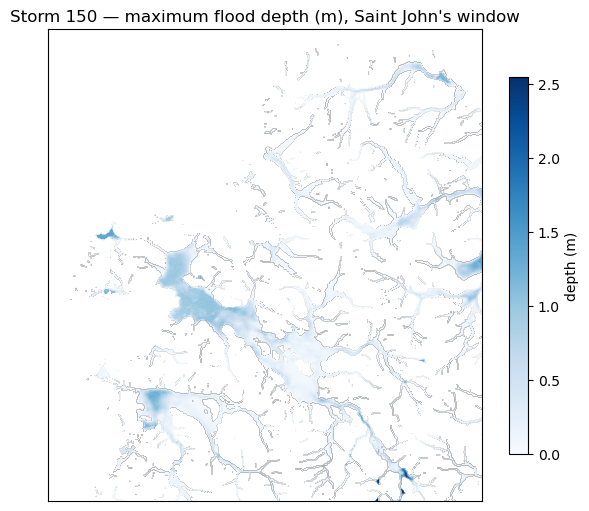

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
shown = np.where(one_storm >= attrs["extent_threshold_m"], one_storm, np.nan)
im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=2.55)
ax.set_title(f"Storm {STORM} — maximum flood depth (m), Saint John's window")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="depth (m)", shrink=0.7)
plt.show()

## 2. The storm index

Storm 150 is a position, not a name. The store's `index.csv` maps each position to the
scenario it came from (`storm_id`) and its rainfall total (`magnitude_mm`), sorted by
magnitude — so stepping through the positions walks *severity*.

Per-storm statistics are cheap for *one* storm but expensive for all 200. The
Guatemala store ships a precomputed summary beside the arrays; this one does not yet,
so we read the `extent` array (a 0/1 wet mask, cheaper than depth) for every tenth
storm to see how the flooded area grows.

200 storms, rainfall totals 0.01 to 1119.99 mm, sorted: True


,storm_index,storm_id,magnitude_mm
0,0,sample_0003,0.01
1,1,sample_0002,0.14
2,2,sample_0004,0.35
100,100,sample_0089,256.40
150,150,sample_0169,385.02
199,199,sample_0199,1119.99


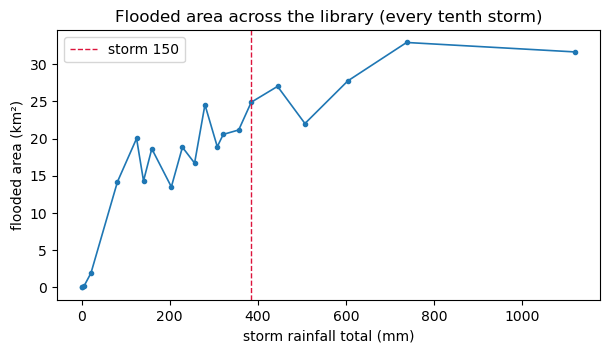

In [6]:
index = pd.read_csv(f"{STORE}/index.csv")
print(f"{len(index)} storms, rainfall totals {index.magnitude_mm.min():g} to "
      f"{index.magnitude_mm.max():g} mm, sorted: {index.magnitude_mm.is_monotonic_increasing}")
display(index.iloc[[0, 1, 2, 100, 150, 199]])

# Cell area from the grid: one arc-second is 30.9 m north-south, and
# 30.9 * cos(latitude) east-west.
lat = attrs["transform"][5] - 0.5 * attrs["grid_shape"][0] * attrs["transform"][0]
cell_m2 = (30.87 ** 2) * np.cos(np.radians(lat))

sample = list(range(0, 200, 10)) + [199]
extent = group["extent"]
area_km2 = [np.asarray(extent[i]).sum() * cell_m2 / 1e6 for i in sample]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(index.magnitude_mm[sample], area_km2, marker="o", ms=3, lw=1.2)
ax.axvline(index.magnitude_mm[STORM], color="crimson", ls="--", lw=1, label=f"storm {STORM}")
ax.set_xlabel("storm rainfall total (mm)"); ax.set_ylabel("flooded area (km²)")
ax.set_title("Flooded area across the library (every tenth storm)")
ax.legend(); plt.show()

Storm 0 has a rainfall total of 0.01 mm and never wets a cell. Zarr omits chunks that
are entirely fill-value, so its chunk was never written and reading it returns zeros.
The usable range starts at storm 1 — and even that one floods nothing above 5 cm.

## 3. The buildings and roads of Saint John's

The exposure data is the IBF geopackage for the whole country — 71,136 buildings and
9,315 road segments built from Overture Maps — with the four exceedance probabilities
of Exercise 3 already attached. Here we only want the features inside Saint John's
parish, so the read is filtered on the parish code before anything leaves the file.

Reading a 27 MB geopackage straight off HTTPS goes through GDAL's `/vsicurl`, which
range-requests the file once per layer; downloading it once is much faster.

In [7]:
import tempfile
import urllib.request
from pathlib import Path

import pyogrio


def cached(url):
    """Fetch once into the temp dir and return the local path."""
    path = Path(tempfile.gettempdir()) / url.rsplit("/", 1)[-1]
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path


source = cached(FEATURES)
LAYERS = {
    "building": ("AntiguaBarbuda_Jerry_cycle_10151010_bldgs",
                 ["feature_id", "subtype", "population_per_building", "building_area_m2", "wrldpp_sum"]),
    "road": ("AntiguaBarbuda_Jerry_cycle_10151010_roads", ["feature_id", "road_length_m"]),
}

parts = []
for type_, (layer, columns) in LAYERS.items():
    part = pyogrio.read_dataframe(source, layer=layer, columns=columns,
                                  where=f"GID_1 = '{PARISH}'", use_arrow=True)
    part["type"] = type_
    parts.append(part)
features = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)

# A road has no population and a building no length: fill so every row sums.
for col in ["population_per_building", "building_area_m2", "road_length_m"]:
    features[col] = features[col].fillna(0.0)

print(f"{len(features):,} features in Saint John's  |  CRS {features.crs.to_string()}")
print(features["type"].value_counts().to_string())
print()
features[["type", "subtype", "population_per_building", "building_area_m2", "road_length_m"]].head(3)

41,009 features in Saint John's  |  CRS EPSG:32620
type
building    36318
road         4691



,type,subtype,population_per_building,building_area_m2,road_length_m
0,building,None,0.07,38.63,0.0
1,building,None,0.29,161.98,0.0
2,building,None,2.51,154.71,0.0


`population_per_building` is a **per-building** estimate: the parish population from
the Statistics Division, spread over the residential buildings by their built-up
area. It is not a census count, and the data package says so. A trap worth knowing
about: the `wrldpp_sum` column next to it repeats the whole *parish* total on every
building. Summing that one overstates exposure by four orders of magnitude. Always
check whether a population field is a total or a disaggregation.

In [8]:
n_buildings = int((features["type"] == "building").sum())
print(f"sum of population_per_building : {features.population_per_building.sum():>16,.0f}   <- people in Saint John's")
print(f"sum of wrldpp_sum              : {features.wrldpp_sum.sum():>16,.0f}   <- the parish total, {n_buildings:,} times over")

sum of population_per_building :           56,368   <- people in Saint John's
sum of wrldpp_sum              :    2,047,172,661   <- the parish total, 36,318 times over


## 4. Sampling depth onto each feature

We want, for each building, **the deepest water anywhere on its footprint**. That is
the conservative reading, and it matches how the IBF probabilities in Exercise 3 were
sampled, so the two products stay comparable.

Doing this one feature at a time would be slow, and the usual shortcut — burn each
feature's id into a grid once, then read depths back by id — does not work here. At
30 m a cell is bigger than most buildings, and in St. John's many buildings share one
cell, so burning ids keeps only the last one and silently drops the rest (try it with
`rasterio.features.rasterize`: only about 39% of the features survive). The grid is
coarse relative to the features, so the sampling has to allow **many features per
cell**.

Instead, build the list of (feature, cell) pairs once:

1. For each feature, take the cells its bounding box covers — a handful each.
2. Keep only the pairs where the feature actually touches the cell. This is a
   vectorised intersection test, so it is one call, not 41,000.
3. For each storm, take the maximum depth per feature over its pairs with
   `np.maximum.at`, a single pass over the pairs.

Only step 3 depends on the storm, so steps 1 and 2 are paid once and reused for all
200. The features are stored in UTM zone 20N and the store is EPSG:4326, so they are
reprojected onto the store's own grid first — cheap, because it is vector data.

In [9]:
import shapely

zarr_transform = rasterio.Affine(*attrs["transform"])
rows, cols = attrs["grid_shape"]
features = features.to_crs(attrs["crs"])

# 1. The cells each feature's bounding box covers. Row 0 is the top edge and the
#    cell height `e` is negative, so the first row comes from the *maximum* y.
a, _, x0, _, e, y0 = zarr_transform[:6]
minx, miny, maxx, maxy = features.geometry.bounds.to_numpy().T
c0 = np.clip(np.floor((minx - x0) / a).astype(int), 0, cols - 1)
c1 = np.clip(np.floor((maxx - x0) / a).astype(int), 0, cols - 1)
r0 = np.clip(np.floor((maxy - y0) / e).astype(int), 0, rows - 1)
r1 = np.clip(np.floor((miny - y0) / e).astype(int), 0, rows - 1)

n_cells = (r1 - r0 + 1) * (c1 - c0 + 1)
feature_idx = np.repeat(np.arange(len(features)), n_cells)
# Position of each candidate inside its feature's window, unrolled row by row.
within = np.arange(n_cells.sum()) - np.repeat(np.cumsum(n_cells) - n_cells, n_cells)
width = np.repeat(c1 - c0 + 1, n_cells)
row = np.repeat(r0, n_cells) + within // width
col = np.repeat(c0, n_cells) + within % width

# 2. Keep the pairs where the feature really touches the cell.
cell_boxes = shapely.box(x0 + col * a, y0 + (row + 1) * e, x0 + (col + 1) * a, y0 + row * e)
touches = shapely.intersects(features.geometry.to_numpy()[feature_idx], cell_boxes)
feature_idx, cell_idx = feature_idx[touches], (row * cols + col)[touches]

sampled = np.unique(feature_idx)
print(f"{len(feature_idx):,} (feature, cell) pairs kept from {n_cells.sum():,} candidates")
print(f"{len(sampled):,} of {len(features):,} features touch at least one cell "
      f"({100 * len(sampled) / len(features):.1f}%)")
print(f"{len(np.unique(cell_idx)):,} of {rows * cols:,} cells carry a feature; "
      f"the busiest carries {np.bincount(cell_idx).max():,}")

92,183 (feature, cell) pairs kept from 122,302 candidates
41,009 of 41,009 features touch at least one cell (100.0%)
34,236 of 199,020 cells carry a feature; the busiest carries 16


Every feature keeps at least one cell, and a cell now carries as many features as sit
in it. That coverage line is the check to run whenever a sampling method meets a new
grid: the Guatemala notebooks burn ids and lose nothing, because there the cells are
5 m and a building covers many of them. Same code, different grid, different answer.

In [10]:
def feature_max_depth(storm_index):
    """Deepest water over each feature's own footprint, in metres."""
    layer = np.asarray(depth[storm_index], dtype="float32").ravel()
    # Anything non-finite or negative is "no water", not a depth.
    layer = np.where(np.isfinite(layer) & (layer > 0), layer, 0.0)

    per_feature = np.zeros(len(features), dtype="float32")
    np.maximum.at(per_feature, feature_idx, layer[cell_idx])   # one pass over the pairs
    return per_feature


depths = feature_max_depth(STORM)
print(f"storm {STORM}: {int((depths >= attrs['extent_threshold_m']).sum()):,} features touched by water")
print(f"  deepest single feature: {depths.max():.2f} m")

storm 150: 8,043 features touched by water
  deepest single feature: 1.00 m


## 5. Depth bands

Now group the depths into bands. These are the bands the dashboard plugins use — round
numbers chosen so each one reads without a legend: roughly ankle, knee, and above
head height. The 0.05 m floor is the store's own `extent_threshold_m`, not a number we
invented, and the top band starts at 2 m because the store cannot distinguish depths
above 2.55 m.

Assign in **ascending** order and let later assignments win, so each feature ends up
in the deepest band it reaches.

In [11]:
DEPTH_BANDS = [          # (class value, colour, lower bound in metres)
    (1, "green", 0.05),
    (2, "yellow", 0.30),
    (3, "red", 1.00),
    (4, "purple", 2.00),
]
BAND_LABEL = {1: "0.05 - 0.3 m", 2: "0.3 - 1 m", 3: "1 - 2 m", 4: "2 m or more"}


def classify_depth(values):
    band = np.zeros(len(values), dtype="uint8")     # 0 = dry
    for value, _colour, floor in DEPTH_BANDS:
        band[values >= floor] = value               # deepest band wins
    return band


features["depth_m"] = depths
features["band"] = classify_depth(depths)
features["level"] = features.band.map(BAND_LABEL)

pd.crosstab(features["band"].map({0: "dry", **BAND_LABEL}), features["type"]).reindex(["dry", *BAND_LABEL.values()], fill_value=0)

type,building,road
band,,
dry,29491,3475
0.05 - 0.3 m,6200,1084
0.3 - 1 m,626,132
1 - 2 m,1,0
2 m or more,0,0


> ⚠️ **Classify before you round.** If you round the depths to 2 decimals first and
> *then* classify, a feature sitting at 0.0455 m rounds up to 0.05 and gets promoted
> into the wet band. That is a display concern silently changing the answer. Round
> only what you print.

## 6. The impact table

Deepest band first, so the worst case is read first, with a total across every
affected feature. The population share is against the parish: the sum of
`population_per_building` over every building in Saint John's, which is also what
the geopackage's parish summary layer reports as `total_pop`.

In [12]:
TOTAL_POPULATION = features.population_per_building.sum()      # every building in the parish
print(f"Saint John's population across all buildings: {TOTAL_POPULATION:,.0f}")


def impact_row(name, group):
    buildings = group[group["type"] == "building"]
    return {
        "Depth": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.population_per_building.sum():,.0f}",
        "Area (m²)": f"{group.building_area_m2.sum():,.0f}",
        "Roads (km)": f"{group.road_length_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.population_per_building.sum() / TOTAL_POPULATION:.2f}%",
    }


affected = features[features.band > 0]
# Note: not `rows` -- that name already holds the grid height.
table_rows = [impact_row(BAND_LABEL[v], affected[affected.band == v]) for v, _c, _f in reversed(DEPTH_BANDS)]
table_rows.append(impact_row("TOTAL affected", affected))

pd.DataFrame(table_rows).set_index("Depth")

Saint John's population across all buildings: 56,368


,Buildings,Population,Area (m²),Roads (km),% of population
Depth,,,,,
2 m or more,0,0,0,0.0,0.00%
1 - 2 m,1,0,22,0.0,0.00%
0.3 - 1 m,626,777,"52,065",26.9,1.38%
0.05 - 0.3 m,"6,200","9,372","640,979",138.6,16.63%
TOTAL affected,"6,827","10,149","693,066",165.5,18.01%


## 7. Mapping it

The affected features, coloured by depth band, drawn over the depth raster.

/tmp/ipykernel_2950085/2081493809.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()        # polygons and lines share a label


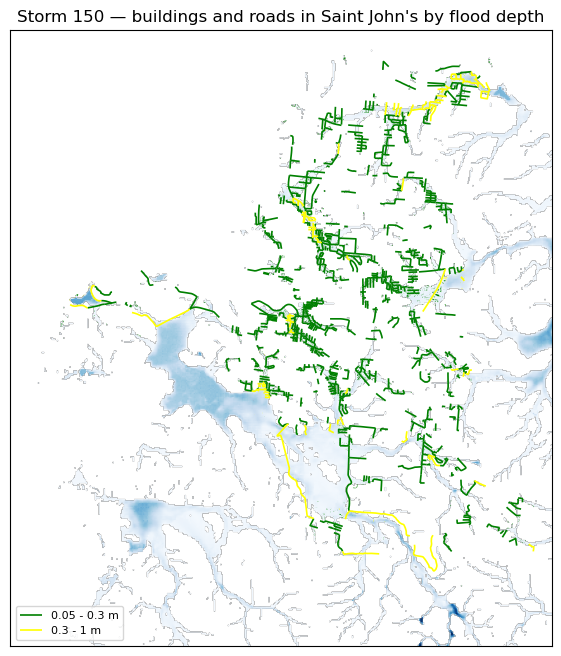

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
left, bottom, right, top = rasterio.transform.array_bounds(rows, cols, zarr_transform)
ax.imshow(shown, cmap="Blues", vmin=0, vmax=2.55, extent=(left, right, bottom, top))

for value, colour, _floor in DEPTH_BANDS:
    subset = features[features.band == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, label=BAND_LABEL[value])

ax.set_title(f"Storm {STORM} — buildings and roads in Saint John's by flood depth")
ax.set_xticks([]); ax.set_yticks([])
handles, labels = ax.get_legend_handles_labels()        # polygons and lines share a label
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="lower left", fontsize=8)
plt.show()

Only features that reach a band are drawn. Dry ones are the large majority and add
nothing a basemap does not already show — dropping them also shrinks the payload
from tens of thousands of features to a few thousand, which matters when it is
re-fetched every time the storm changes.

## 8. Impact across the library

Section 4 paid for the rasterisation once. Re-using it, sampling another storm costs
one chunk read and one pass over the cells, so sweeping the library is cheap. Because
the magnitudes are real rainfall totals, the x-axis below is in millimetres and means
what it says.

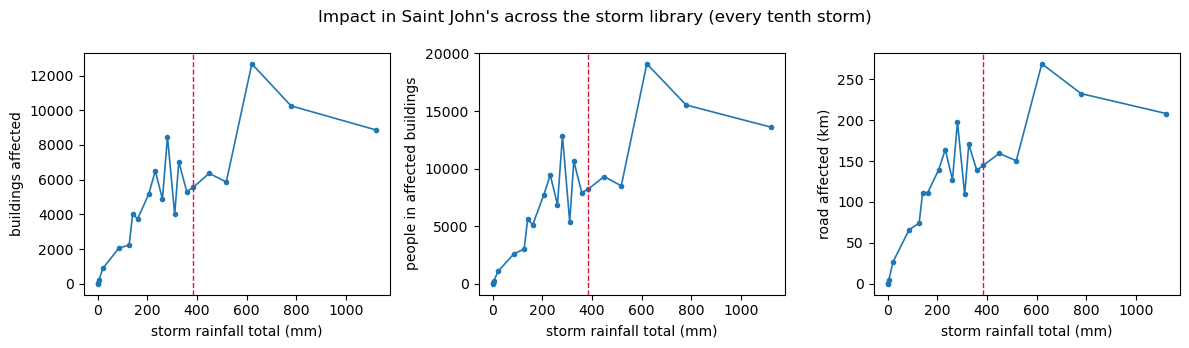

In [14]:
sweep = list(range(1, 200, 10)) + [199]
records = []
for i in sweep:
    band = classify_depth(feature_max_depth(i))
    hit = features[band > 0]
    records.append({"storm": i, "magnitude_mm": index.magnitude_mm[i],
                    "buildings": int((hit["type"] == "building").sum()),
                    "population": hit.population_per_building.sum(),
                    "roads_km": hit.road_length_m.sum() / 1000})
across = pd.DataFrame(records).set_index("storm")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, label in zip(axes, ["buildings", "population", "roads_km"],
                          ["buildings affected", "people in affected buildings", "road affected (km)"]):
    ax.plot(across.magnitude_mm, across[col], marker="o", ms=3, lw=1.2)
    ax.axvline(index.magnitude_mm[STORM], color="crimson", ls="--", lw=1)
    ax.set_xlabel("storm rainfall total (mm)"); ax.set_ylabel(label)
fig.suptitle("Impact in Saint John's across the storm library (every tenth storm)")
fig.tight_layout(); plt.show()

The curves are not monotonic. The library is sorted by the parish-mean rainfall
total, but the flooded footprint depends on *where* in the parish the rain fell and
how fast, so a larger total does not guarantee more buildings under water. Magnitude
orders the library; it does not order the impact. That is why the forecast matches a
member to a storm by total and then reads the impact off the depth map, never off the
magnitude.

## 9. From library to forecast: rebuilding Exercise 3's raster

A forecast cycle does not compute new flood maps. Each of its 50 rainfall members has
a total over the parish; the member is matched to a library storm, and that storm's
depth map stands in for the member. **P(depth ≥ 30 cm)** at a cell is then the share
of the 50 members whose matched storm floods that cell to 30 cm — which is what the
probability rasters of Exercise 3 hold.

This can be checked rather than asserted. The Tropical Storm Jerry cycle of
2025-10-10 01:00 UTC published a `member_decisions.csv` **per parish**, including Saint
John's, and it records the storm each member was matched to — so the reconstruction
below can be compared cell for cell against the `prob_depth_ge_30cm` raster the run
shipped for this parish.

Read the matching rule off the data rather than guessing it. `p_rule` says
`pluvial_band` for every member, and the matched storm's magnitude is always *at or
above* the member's total: it is the smallest library storm that covers the member, a
deliberately conservative ceiling. Guessing "nearest magnitude" instead reproduces
fewer than a fifth of the choices here, and the rebuilt raster is then visibly wrong.

In [15]:
# The cycle writes one decision file per parish; this is Saint John's own, so what
# follows is this parish's forecast rather than an illustration of the method.
SITE = (f"{BUCKET}/AnB_training/AB_Jerry_cycle_20251010_0100_workshop/"
        "AB_Jerry_cycle_20251010_0100_workshop/fim_all_sites/Antigua_SaintJohnS")
decisions = pd.read_csv(f"{SITE}/member_decisions.csv")
print(f"{len(decisions)} forecast members; rainfall totals "
      f"{decisions.total_mm.min():.1f} to {decisions.total_mm.max():.1f} mm")
print(f"matching rules used: {decisions.p_rule.unique().tolist()}")

# The run's own answer: p_storm names the scenario, index.csv gives its position.
position_of = dict(zip(index.storm_id, index.storm_index))
decisions["matched_storm"] = decisions.p_storm.map(position_of).astype(int)
print(f"distinct library storms matched: {decisions.matched_storm.nunique()} "
      f"for {len(decisions)} members")

# Reading the rule off the data beats assuming one.
order = index.magnitude_mm.to_numpy()
totals = decisions.total_mm.to_numpy()
ceiling = np.searchsorted(order, totals, side="left")       # smallest storm >= total
nearest_pos = np.clip(np.searchsorted(order, totals), 1, len(order) - 1)
closer_below = np.abs(order[nearest_pos - 1] - totals) <= np.abs(order[nearest_pos] - totals)
nearest = np.where(closer_below, nearest_pos - 1, nearest_pos)
print(f'  "smallest storm >= member total" reproduces '
      f'{100 * (ceiling == decisions.matched_storm).mean():.0f}% of the choices')
print(f'  "nearest magnitude"              reproduces '
      f'{100 * (nearest == decisions.matched_storm).mean():.0f}%')

50 forecast members; rainfall totals 40.0 to 144.5 mm
matching rules used: ['pluvial_band']
distinct library storms matched: 5 for 50 members
  "smallest storm >= member total" reproduces 100% of the choices
  "nearest magnitude"              reproduces 18%


distinct probability values: 9   max 1.00
largest difference from the published raster: 0.000000
cells differing: 0 of 199,020


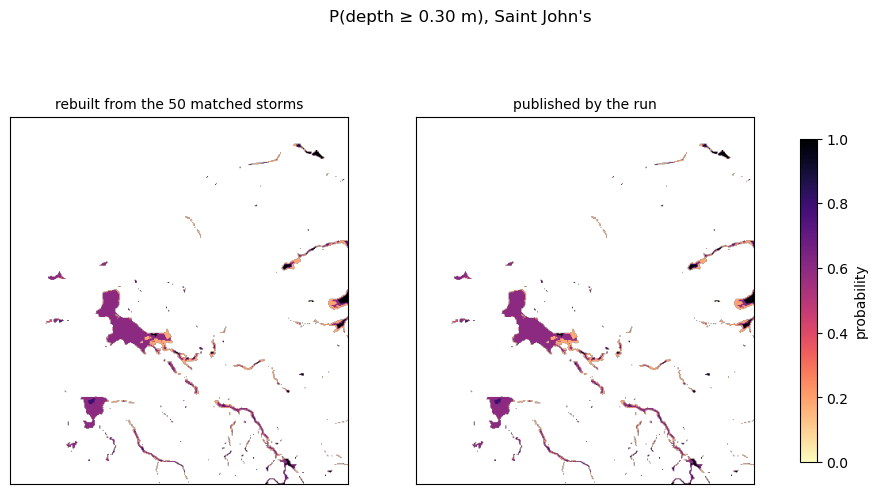

In [16]:
# P(depth >= 0.30 m) = share of members whose matched storm reaches 30 cm at the cell.
count = np.zeros((rows, cols), dtype="int32")
for i in decisions.matched_storm:
    count += np.asarray(depth[int(i)]) >= 0.30
prob_30 = count / len(decisions)

# The run shipped this raster. Rebuilding it is the check that the mechanism above is
# the mechanism that actually produced Exercise 3's inputs.
with rasterio.open(f"{SITE}/pluvial/prob_depth_ge_30cm.20251010.010000.tif") as ds:
    delivered = ds.read(1)

print(f"distinct probability values: {len(np.unique(prob_30))}   max {prob_30.max():.2f}")
print(f"largest difference from the published raster: {np.abs(prob_30 - delivered).max():.6f}")
print(f"cells differing: {int((np.abs(prob_30 - delivered) > 1e-6).sum()):,} of {prob_30.size:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, grid, title in zip(axes, [prob_30, delivered],
                           ["rebuilt from the 50 matched storms", "published by the run"]):
    im = ax.imshow(np.where(grid > 0, grid, np.nan), cmap="magma_r", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("P(depth ≥ 0.30 m), Saint John's")
fig.colorbar(im, ax=axes, label="probability", shrink=0.7)
plt.show()

## 10. How the dashboard plugins do it

Everything above runs here, in a notebook. To put it on a dashboard the same code has
to become a **plugin**: an installable Python package that TethysDash finds on its own
and runs for the frontend.

The `tgf_wmo_plugins` package ships a storm family — `wmo_storm_card_*`,
`wmo_storm_impact_summary_*`, `wmo_storm_impact_layer_*` — that does exactly sections
3 to 6 for the Guatemala ensemble. It is **not yet wired to the Antigua and Barbuda
libraries**: its store URL, storm count and magnitude labels are module constants for
the Guatemala store. What a Saint John's variant needs is small, and worth reading as
a checklist of what this notebook hard-coded:

- the store URL and the parish filter (sections 1 and 3)
- the `index` argument's dropdown options: the storm positions as values,
  `magnitude_mm` from `index.csv` as labels — real millimetres this time
- a precomputed per-storm summary beside the store, because reading all 200 storms per
  request is what section 8 avoided doing for real

### Discovery — how the app finds it

A plugin is a class registered as an **Intake entry point** in its package's
`pyproject.toml`:

```toml
[project.entry-points."intake.drivers"]
wmo_storm_impact_summary_en = "tgf_wmo_plugins.storm_impact_summary:StormImpactSummaryEN"
wmo_storm_impact_layer_en   = "tgf_wmo_plugins.storm_impact_layer:StormImpactLayerEN"
wmo_storm_card_en           = "tgf_wmo_plugins.storm_card:StormCardEN"
```

Once the plugin is installed with TethysDash, users can integrate it into their own
dashboards to view the results.

### The class — discovery properties, args, and one method

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class StormImpactSummaryEN(TethysDashPlugin):

    # ---- discovery: how the GUI lists and presents this plugin -----------
    name = "wmo_storm_impact_summary_en"      # must match the entry-point key
    label = "Storm Impact Summary (English)"  # the row in the dropdown
    group = "Flood Maps (English)"            # the heading it is filed under
    description = "People, buildings and roads by flood depth for one storm."
    tags = ["flood", "impact", "zarr", "storm", "table", "english"]

    # ---- what kind of visualization this is ------------------------------
    type = "table"
    # `type` picks the frontend renderer, and therefore dictates the shape
    # run() must return. One of: table, card, plotly, image, text,
    # variable_input, map, map_layer, custom.

    # ---- what the GUI asks the dashboard author to fill in ---------------
    args = {
        "index": STORM_OPTIONS,   # a list of {"value", "label"} -> a dropdown
        # "number" / "text" / "checkbox" / "date" -> the matching input widget
    }
    # The arg *names* are the contract: they are the keys a dashboard stores,
    # so renaming one silently breaks every dashboard already using it. The GUI
    # derives each field's label from the name, so `index` displays as "Index".

    def run(self):
        """Called once per request, and again whenever a bound arg changes."""

        index = self.get_arg("index", 2)
        # get_arg() reads a configured value. If the author bound this arg to a
        # variable input, the "${Storm}" reference is already resolved by now --
        # the plugin never sees the template syntax.

        gdf = banded_features(index)
        # ^ sections 3 to 5: load the features, sample the deepest water on
        #   each footprint, attach a depth band.

        # A `table` returns a title and a list of row dicts. Keys become the
        # columns in order; values are preformatted strings, because how a
        # number should read is a decision the renderer cannot make.
        return {"title": f"Storm {index}", "data": [{"Depth": "...", "Buildings": "..."}]}
```

Both language variants subclass one shared base that holds `run()`; the subclasses
set only `name`, `label`, `group`, `tags` and which string table to use. Nothing that
computes a number is duplicated.

### Map layers implement two methods, not one

A `map_layer` plugin is asked two different questions at two different times, so it
answers them separately:

```python
class StormImpactLayerEN(TethysDashPlugin):
    name = "wmo_storm_impact_layer_en"
    label = "Storm Impact Layer (English)"
    group = "Flood Maps (English)"
    type = "map_layer"
    dynamic_map_layer = True     # this flag is what enables fetch_features()
    args = {"index": STORM_OPTIONS}

    def run(self):
        """CONFIGURE time. Called once, when the author adds the layer.

        Returns the layer's *scaffold*, not its data: a name, a source binding,
        style rules and a legend. This is what the layer editor's
        "Fetch plugin defaults" button calls.
        """
        builder = LayerConfigurationBuilder("Flooded buildings and roads", "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NOT self.args. self.args is the *schema*; the runtime
        # re-invocation needs the configured *values*, including any "${Storm}"
        # binding that still has to be resolved on each fetch.

        builder.set_style(...)    # rules keyed on a feature attribute (`banda`)
        builder.set_legend(...)   # what the map legend shows for this layer
        return builder.build()    # -> the layer configuration dict

    def fetch_features(self):
        """RUN time. Called on load, and again every time `${Storm}` changes.

        Returns GeoJSON. This is the only part that re-executes.
        """
        self.send_update("Sampling depth...", percentage_complete=10)
        # send_update() streams progress to the tile over a WebSocket, so a
        # recompute that takes a few seconds looks busy rather than broken.

        gdf = banded_features(self.get_arg("index", 2))
        return {"type": "FeatureCollection",
                "features": [...],                     # one per affected feature
                "crs": {"type": "name", "properties": {"name": "EPSG:4326"}}}
```

### The three plugins built on this kind of data

| plugin | `type` | `run()` returns |
|---|---|---|
| `wmo_storm_impact_summary_*` | `table` | `{"title", "data": [row dicts]}` — the table from section 6 |
| `wmo_storm_impact_layer_*` | `map_layer` | a layer scaffold; `fetch_features()` then returns the GeoJSON behind section 7 |
| `wmo_storm_card_*` | `card` | `{"data": [{"color", "label", "value", "icon"}]}` — headline figures, no title |

### Why the two-method split earns its keep

`run()` fires once, when someone is configuring the dashboard. `fetch_features()`
fires on every change to a bound variable. Putting the style and legend in `run()`
means they are computed once and stored with the dashboard, so changing the storm
re-runs only the part that actually depends on the storm.

All three plugins import one core module that caches the storm-independent step.
Building the (feature, cell) pairs is paid once per process — section 4 — and
changing the storm re-reads one chunk and re-runs a single pass over the pairs.

### Things to try

- Change `STORM` in section 1 and re-run. Storm 1 is dry; 199 is the largest in the
  library. Look up storm 150's rainfall total in section 2, then find the storm
  closest to the 167 mm that V.C. Bird airport recorded in four hours during Tropical
  Storm Jerry.
- Change the `DEPTH_BANDS` bounds. What happens to the table if you add a
  `1.5 m or more` band? What *cannot* happen if you add a `3 m or more` band, and why?
- Section 4 takes the **maximum** depth over each footprint. Try the mean instead
  (`np.add.at` and a count) and see how the table changes. Which is the more
  defensible number to give a decision-maker?
- Replace section 4 with `rasterio.features.rasterize` burning feature ids, as the
  Guatemala notebook does, and re-run. How many features vanish, and does the impact
  table go up or down?
- In section 9, swap the run's own `matched_storm` for the `nearest` array computed
  beside it and re-run. The published raster is no longer reproduced. How wrong does
  it look, and would you have noticed without something to compare against?
- Open another parish — `AG08_SaintPhilip_v1.zarr` with `PARISH = "ATG.8_1"`, and
  `Antigua_SaintPhilip` in section 9 — and re-run. Every parish has its own library,
  its own member totals and its own published rasters, so the reconstruction should
  come out exact there too.